## OBJECTIVE 2



# YOLOv8 for Vehicle Detection and Traffic Analysis

In this project, we are using the **YOLOv8 (You Only Look Once)** model for real-time object detection. Specifically, we'll be detecting vehicles in images and videos for traffic monitoring and route optimization. This notebook will guide you through the steps of setting up YOLOv8, training the model, and performing object detection on test images.










---




## Import Libraries and Mount Google Drive

In [ ]:
#connecting with google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [37]:
#importing necessary libraries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import seaborn as sns
from ultralytics import YOLO
import torch
import numpy as np

## Install the Necessary Libraries




The first step is to install the **Ultralytics YOLOv8** library, which provides tools to load and use pre-trained YOLOv8 models.

In [ ]:
import locale
locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

'en_US.UTF-8'

In [ ]:
  !pip install ultralytics
  from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

## Training Data

### Loading and Training the Pre-trained YOLOV8 model

In [ ]:
# Load a pre-trained YOLOv8 model (use 'yolov8n.pt' for speed, 'yolov8s.pt' for accuracy)
model = YOLO("yolov8s.pt")

# Train the model
model.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=50, imgsz=640, batch=16, workers=2)


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, sho

100%|██████████| 755k/755k [00:00<00:00, 97.0MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 319MB/s]


AMP: checks passed ✅


...

                   all        182        272      0.848      0.819      0.866      0.599



50 epochs completed in 0.244 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 22.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.93it/s]


                   all        182        272       0.84      0.818      0.865      0.601
              bodaboda         45         64      0.846      0.862      0.894      0.549
                   bus         51         67      0.815      0.716      0.796      0.554
                matatu         55         77      0.803      0.741      0.801      0.609
                tuktuk         51         64      0.895      0.953      0.971      0.691
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba772abd310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

#### **The YOLOv8 model performs well with high precision and recall, making it suitable for vehicle detection. However, mAP50-95 suggests there's room for improvement in detecting objects with stricter IoU thresholds. Next steps: experiment with data augmentation or fine-tuning to improve mAP50-95.**

#Loading the best model

In [12]:
 # Load best model
model = YOLO("runs/detect/train2/weights/best.pt")


## Testing the Model on Sample Images

In [13]:
results = model.predict("/content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_151.jpg")


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_151.jpg: 448x640 1 bodaboda, 40.1ms
Speed: 2.0ms preprocess, 40.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


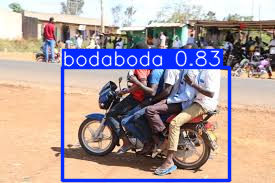

In [18]:
results[0].show()

## Run validation
Run validation on the model to evaluate its performance and obtain key metrics.


In [15]:
# Run validation
metrics = model.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", conf=0.5)

# Print key metrics
print(metrics)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/.shortcut-targets-by-id/1CTNiSkliI5dTDURDOllVL50wQhbNL9ZH/dataset_2/valid/labels.cache... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.29it/s]


                   all        182        272       0.89       0.77       0.86      0.649
              bodaboda         45         64      0.898      0.781      0.862      0.585
                   bus         51         67      0.852      0.687      0.807      0.623
                matatu         55         77      0.875      0.675      0.812      0.663
                tuktuk         51         64      0.938      0.938       0.96      0.726
Speed: 1.3ms preprocess, 8.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba77263db90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0

### **The model performs well with high precision  but shows some room for improvement in recall  and mAP50-95. The inference time is acceptable for real-time applications. Further tuning or data augmentation could help boost recall and mAP at stricter IoU thresholds.**

### Detecting Objects in an Image


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg: 384x640 2 tuktuks, 42.5ms
Speed: 3.4ms preprocess, 42.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


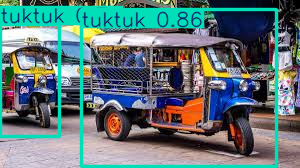

In [19]:
# Load and detect objects in an image
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()  # Display image with bounding boxes


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_055.jpg: 480x640 1 bodaboda, 42.2ms
Speed: 3.3ms preprocess, 42.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


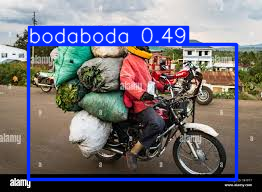

In [20]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/image_cleaned_batch 5/Overloading/overloading_055.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()  # Display image with bounding boxes

# Data Augmentation

## Training the YOLOv8 Model

In this section, we will train a YOLOv8 model on our custom dataset. We will be using several data augmentation techniques and hyperparameters that are carefully selected to improve the model's performance and robustness.

### Hyperparameters and Data Augmentation:

- **Epochs**: The model will be trained for 50 epochs. This allows the model to make multiple passes through the dataset to learn and adjust.
- **Image Size (imgsz)**: We resize all input images to 640x640 pixels, ensuring a standard input size for the model.
- **Batch Size (batch)**: We use a batch size of 16, which balances memory usage and training speed.
  
### Data Augmentation Techniques:
- **HSV Augmentation**: The hue, saturation, and value (brightness) will be slightly altered during training to improve the model's ability to handle different lighting conditions. The values are set as follows:
  - **Hue**: 0.015
  - **Saturation**: 0.7
  - **Value**: 0.4
- **Flip Augmentation**: We apply random flips to the images to make the model more robust to different object orientations:
  - **Vertical Flip Probability**: 0.5
  - **Horizontal Flip Probability**: 0.5
- **Mosaic**: This augmentation randomly combines four images into one, which provides the model with varied contexts and object relationships.
- **MixUp**: During training, the model will sometimes blend images and their associated labels to introduce more variation and improve generalization.

These augmentations should help create a more generalized and robust YOLOv8 model that performs well on real-world object detection tasks.





In [27]:
model2 = YOLO("yolov8s.pt")

model2.train(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", epochs=50, imgsz=640, batch=16,
            hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
            flipud=0.5, fliplr=0.5, mosaic=1.0, mixup=0.2)

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, sho

train: Scanning /content/drive/.shortcut-targets-by-id/1CTNiSkliI5dTDURDOllVL50wQhbNL9ZH/dataset_2/train/labels.cache... 635 images, 0 backgrounds, 0 corrupt: 100%|██████████| 635/635 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/.shortcut-targets-by-id/1CTNiSkliI5dTDURDOllVL50wQhbNL9ZH/dataset_2/valid/labels.cache... 182 images, 0 backgrounds, 0 corrupt: 100%|██████████| 182/182 [00:00<?, ?it/s]


Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/train3
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        182        272      0.854      0.741      0.822      0.554



50 epochs completed in 0.173 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 22.5MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.03it/s]


                   all        182        272      0.836        0.7      0.812      0.556
              bodaboda         45         64      0.902      0.688      0.856      0.498
                   bus         51         67      0.737      0.657      0.739      0.513
                matatu         55         77      0.784       0.61      0.718      0.534
                tuktuk         51         64       0.92      0.844      0.936      0.679
Speed: 0.2ms preprocess, 5.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba5704e4d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

### **The model performs well with high precision but shows room for improvement in recall and mAP50-95. The inference time is acceptable for real-time applications. Further tuning or stronger data augmentation could help improve recall and mAP at higher IoU thresholds.**



## Testing with a sample of images

In [28]:
model = YOLO("runs/detect/train3/weights/best.pt")  # Load best model


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg: 384x640 2 tuktuks, 11.4ms
Speed: 1.8ms preprocess, 11.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


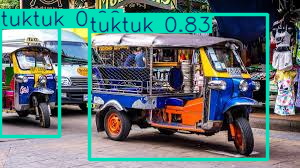

In [29]:
# Load and detect objects in an image
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/tuktuk/tuktuk_006.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()  # Display image with bounding boxes


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/buses/buses_006.jpg: 480x640 1 bus, 1 matatu, 14.2ms
Speed: 2.1ms preprocess, 14.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


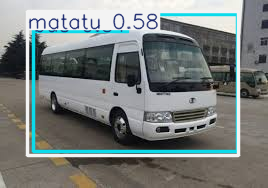

In [30]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/buses/buses_006.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()  # Display image with bounding boxes


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/matatu/matatu_006.jpg: 512x640 1 matatu, 41.1ms
Speed: 2.3ms preprocess, 41.1ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)


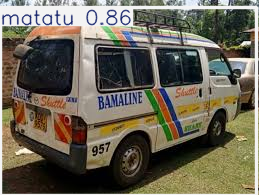

In [31]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/images_cleaned_batch_3/matatu/matatu_006.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()  # Display image with bounding boxes

In [40]:

 # Load image using OpenCV (BGR format)
img = cv2.imread("/content/drive/MyDrive/Capstone_Project_Group1/Test_image _4.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
# Resize image to (224x224) for consistency
img = cv2.resize(img, (224, 224))



0: 640x640 7 buss, 5 matatus, 17.8ms
Speed: 4.5ms preprocess, 17.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


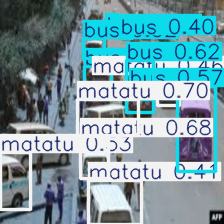

In [41]:
results = model(img)
# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_6.jpeg: 544x640 1 matatu, 42.9ms
Speed: 4.4ms preprocess, 42.9ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)


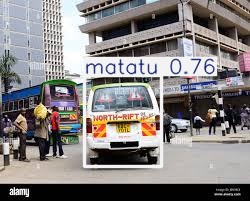

In [42]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/Test_image_6.jpeg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()


image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg: 480x640 1 bodaboda, 1 matatu, 14.0ms
Speed: 2.8ms preprocess, 14.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


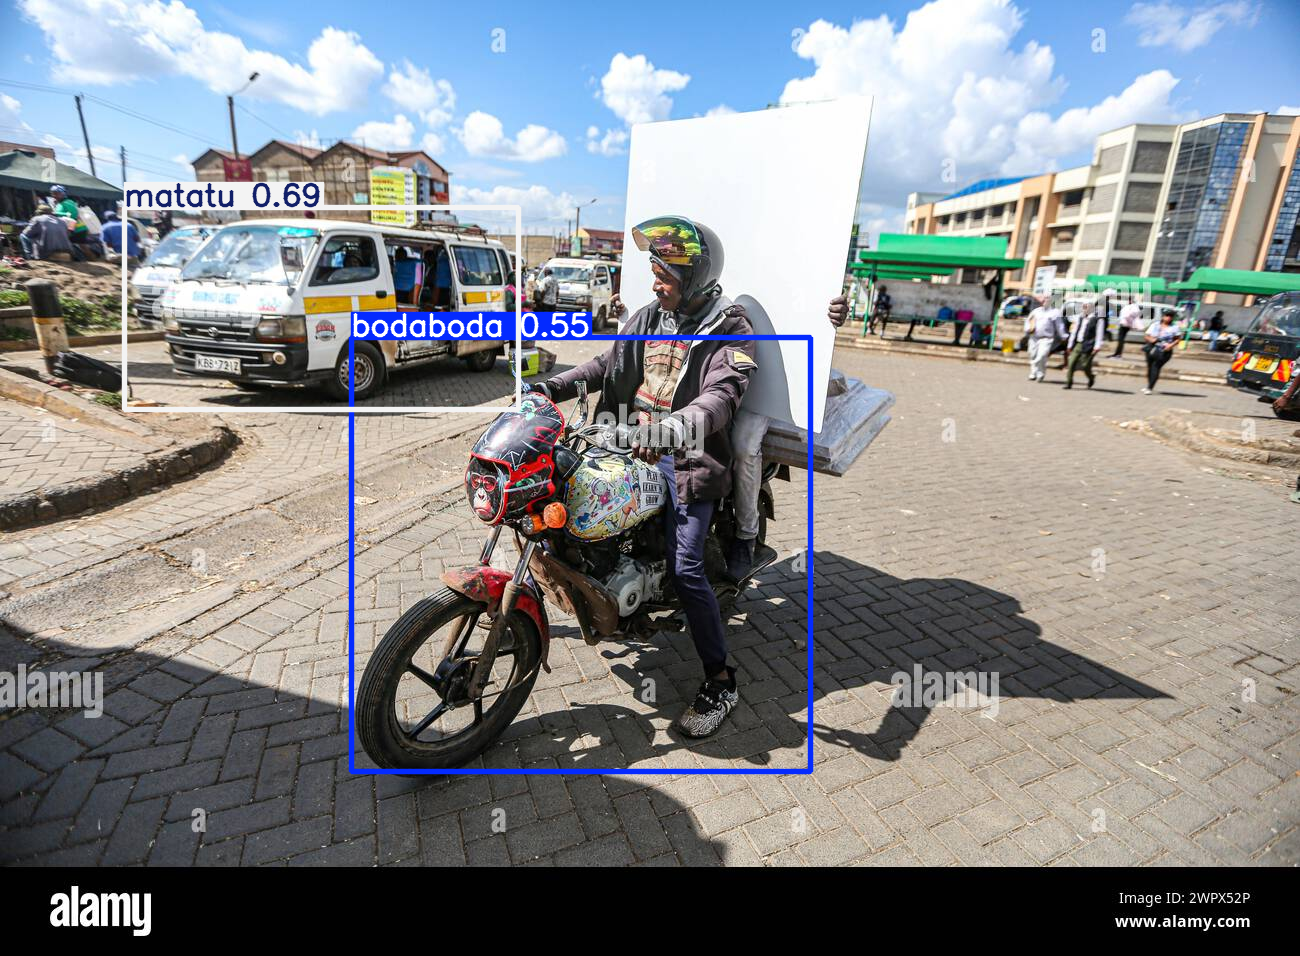

In [43]:
image_path = "/content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg"  # Replace with your test image path
results = model(image_path)

# Show detections
results[0].show()

In [44]:
from collections import Counter

# Load custom class names from the model
custom_class_names = model.names  # Dictionary mapping class IDs to names

# Run inference on an image
results = model("/content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg")

# Count occurrences of each detected class
class_counts = Counter()

for result in results:
    class_ids = result.boxes.cls.tolist()  # Get detected class IDs
    class_counts.update(class_ids)  # Count occurrences

# Display class count with custom names
for class_id, count in class_counts.items():
    class_name = custom_class_names[int(class_id)]  # Get class name from trained model
    print(f"{class_name}: {count} objects")



image 1/1 /content/drive/MyDrive/Capstone_Project_Group1/Test_image_8.jpg: 480x640 1 bodaboda, 1 matatu, 13.2ms
Speed: 2.9ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
matatu: 1 objects
bodaboda: 1 objects


* From the predictions we can see that the model is able to classify most images and detect objects well.

### **Evaluating the metrics of YOLOV8 model**

In [35]:


# Run validation on your dataset
val_results = model.val(data="/content/drive/MyDrive/Capstone_Project_Group1/dataset_2/data.yaml", split="test")

# Extract confusion matrix correctly
conf_matrix = val_results.confusion_matrix  # Correct way to access the confusion matrix

# Convert to a NumPy array for further processing
conf_matrix_np = conf_matrix.cpu().numpy() if isinstance(conf_matrix, torch.Tensor) else np.array(conf_matrix)

# Print Confusion Matrix
print("Confusion Matrix:\n", conf_matrix_np)


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /content/drive/.shortcut-targets-by-id/1CTNiSkliI5dTDURDOllVL50wQhbNL9ZH/dataset_2/test/labels... 91 images, 0 backgrounds, 0 corrupt: 100%|██████████| 91/91 [00:23<00:00,  3.82it/s]

val: New cache created: /content/drive/.shortcut-targets-by-id/1CTNiSkliI5dTDURDOllVL50wQhbNL9ZH/dataset_2/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.34it/s]


                   all         91        119      0.851      0.736      0.834      0.555
              bodaboda         18         29      0.942      0.558      0.787       0.38
                   bus         28         29      0.751       0.69      0.806      0.561
                matatu         26         29      0.796      0.759      0.762      0.586
                tuktuk         28         32      0.914      0.938      0.981      0.694
Speed: 2.2ms preprocess, 9.0ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/detect/val2
Confusion Matrix:


* The model is performing well overall, with a high mAP50 score indicating solid precision and recall at a moderate IoU threshold.
* As for bodaboda,it was difficult getting images that can make the model learn patterns of the bodaboda very well, where the model has high precision but low recall. This suggests the model might be biased toward predicting bodaboda when it detects objects but misses many others.
* tuktuk is the strongest performing class, with high values for all metrics.
* Inference speed is good, making the model suitable for real-time applications.